In [34]:
!pip install corus pymorphy3 navec gensim scikit-learn razdel tqdm -q
!python -m spacy download ru_core_news_sm

Скачивание датасета и эмбеддингов

In [2]:
!wget -q https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz
!wget -q https://storage.yandexcloud.net/natasha-navec/packs/navec_news_v1_1B_250K_300d_100q.tar
!wget -q http://vectors.nlpl.eu/repository/20/184.zip


In [3]:
import zipfile

with zipfile.ZipFile("/content/184.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [5]:
import pandas as pd
import numpy as np
import spacy
import string
import gensim.models
from itertools import islice
from corus import load_lenta
from navec import Navec
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import label_binarize
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

RANDOM_STATE = 2026
np.random.seed(RANDOM_STATE)

Загрузка данных


In [6]:
path = 'lenta-ru-news.csv.gz'
data = list(islice(load_lenta(path), 20000))
df = pd.DataFrame([{'text': r.text, 'topic': r.topic} for r in data])
df = df.dropna().reset_index(drop=True)

Предобработка текстов с кешированием

Токенизация и лемматизация через spaCy и pymorphy3

Преимущества:

Единый пайплайн (токенизация + лемматизация + POS-теги)

Оптимизированная скорость через nlp.pipe()

Корректная обработка сложных случаев (сокращения, дефисы)

In [7]:
import re
from functools import lru_cache
import pymorphy3
from razdel import tokenize

WORD_RE = re.compile(r'^[а-яё]+$', re.IGNORECASE)

morph = pymorphy3.MorphAnalyzer()

@lru_cache(maxsize=10000)
def lemma_token_cached(token):
    if WORD_RE.match(token):
        return morph.parse(token)[0].normal_form
    return token

def preprocess(text):
    if not isinstance(text, str):
        return ''

    text = text.lower()

    tokens = [t.text for t in tokenize(text)]

    tokens = [t for t in tokens if WORD_RE.match(t)]

    tokens = [lemma_token_cached(t) for t in tokens if t]

    return ' '.join(tokens)


In [8]:
df['text_clean'] = [preprocess(text) for text in tqdm(df['text'], desc='Preprocessing', total=len(df))]

Preprocessing:   0%|          | 0/20000 [00:00<?, ?it/s]

Фильтрация редких классов

In [9]:
min_samples = 100
class_counts = df['topic'].value_counts()
valid_classes = class_counts[class_counts >= min_samples].index.tolist()
df = df[df['topic'].isin(valid_classes)].reset_index(drop=True)
df['topic'] = df['topic'].astype('category')

classes = df['topic'].cat.categories.tolist()
y_encoded = df['topic'].cat.codes.values

Разделение 60/20/20 со стратификацией

In [10]:
X = df['text_clean']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.4, random_state=RANDOM_STATE, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
print(f"Classes: {len(classes)}")

Train: 11995, Val: 3998, Test: 3999
Classes: 14


Токенизация для word2vec

In [11]:
train_tokens = [text.split() for text in tqdm(X_train, desc='Tokenizing')]
print(f"Количество документов: {len(train_tokens)}")
print(f"Среднее количество токенов: {np.mean([len(t) for t in train_tokens]):.1f}")

Tokenizing:   0%|          | 0/11995 [00:00<?, ?it/s]

Количество документов: 11995
Среднее количество токенов: 166.4


In [12]:
train_tokens[0]

['сарай',
 'забор',
 'беседка',
 'дорожка',
 'и',
 'другой',
 'объект',
 'некапитальный',
 'строительство',
 'мочь',
 'лишиться',
 'статус',
 'недвижимый',
 'имущество',
 'о',
 'это',
 'сообщить',
 'директор',
 'департамент',
 'недвижимость',
 'минэкономразвития',
 'алексей',
 'бутовецкий',
 'передавать',
 'тасс',
 'так',
 'в',
 'настоящий',
 'время',
 'гражданский',
 'кодекс',
 'рф',
 'указывать',
 'на',
 'то',
 'что',
 'недвижимость',
 'признаваться',
 'земельный',
 'участок',
 'а',
 'также',
 'объект',
 'иметь',
 'прочный',
 'связь',
 'с',
 'земля',
 'перемещение',
 'который',
 'невозможно',
 'без',
 'несоразмерный',
 'ущерб',
 'однако',
 'возникать',
 'вопрос',
 'о',
 'тот',
 'должный',
 'ли',
 'такой',
 'объект',
 'как',
 'забор',
 'замощение',
 'объект',
 'благоустройство',
 'дорожка',
 'называться',
 'недвижимость',
 'отметить',
 'бутовецкий',
 'по',
 'он',
 'слово',
 'министерство',
 'предлагать',
 'уточнить',
 'понятие',
 'недвижимый',
 'имущество',
 'и',
 'разъяснить',
 'он',

Обучение word2vec (Skip-gram)

Гиперпараметры:

vector_size=300: стандартная размерность, баланс между качеством и памятью

window=7: большое окно для тематического сходства (новостные тексты)

min_count=5: отсекаем редкие слова, шум

sg=1: Skip-gram лучше для редких слов

negative=5: оптимально для большого корпуса

epochs=25: достаточное количество итераций

In [13]:
w2v_model = gensim.models.Word2Vec(
    sentences=train_tokens,
    vector_size=300,
    window=7,
    min_count=10,
    sg=1,
    negative=5,
    epochs=20,
    seed=RANDOM_STATE,
)

Внутренняя оценка качества эмбеддингов

In [14]:
w2v_model.wv.most_similar(positive=['май'], topn=5)

[('февраль', 0.46408811211586),
 ('апрель', 0.4283970892429352),
 ('июнь', 0.37896350026130676),
 ('конец', 0.3525155186653137),
 ('тогда', 0.34886911511421204)]

In [15]:
test_words = ['россия', 'сша', 'президент', 'футбол', 'экономика', 'человек', 'матч']
print("\nПокрытие слов в словаре:")
for word in test_words:
    in_vocab = word in w2v_model.wv
    print(f"  '{word}': {'✅' if in_vocab else '❌'}")

print("\ndoesnt_match:")
test_sets = [
    (['россия', 'сша', 'германия', 'яблоко'], 'яблоко'),
    (['футбол', 'хоккей', 'баскетбол', 'книга'], 'книга'),
]
for words, expected in test_sets:
    if all(w in w2v_model.wv for w in words):
        result = w2v_model.wv.doesnt_match(words)
        status = '✅' if result == expected else '⚠️'
        print(f"  {words} → '{result}' {status} (ожидаемо: '{expected}')")

print("\nmost_similar:")
for query in ['президент', 'футбол', 'экономика']:
    if query in w2v_model.wv:
        print(f"\n  '{query}':")
        for word, sim in w2v_model.wv.most_similar(query, topn=5):
            print(f"    {word}: {sim:.4f}")


Покрытие слов в словаре:
  'россия': ✅
  'сша': ✅
  'президент': ✅
  'футбол': ✅
  'экономика': ✅
  'человек': ✅
  'матч': ✅

doesnt_match:
  ['россия', 'сша', 'германия', 'яблоко'] → 'яблоко' ✅ (ожидаемо: 'яблоко')

most_similar:

  'президент':
    путин: 0.5726
    дональд: 0.5366
    трамп: 0.4830
    владимир: 0.4582
    порошенко: 0.4372

  'футбол':
    чемпионат: 0.6392
    сборная: 0.5577
    фифа: 0.5534
    четвертьфинальный: 0.4864
    четвертьфинал: 0.4598

  'экономика':
    ввп: 0.4678
    драйвер: 0.4650
    фондовый: 0.4503
    инфляция: 0.4298
    конкурентоспособный: 0.4276


Загрузка предобученных эмбеддингов

In [16]:
navec = Navec.load('navec_news_v1_1B_250K_300d_100q.tar')

model_path = '/content/model.bin'
rusvectores = gensim.models.KeyedVectors.load_word2vec_format('/content/model.bin' , binary=True)


Функции для векторизации текстов

In [17]:
def text_to_vector_w2v(text, model):
    tokens = text.split()
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(300)

def text_to_vector_navec(text, model):
    tokens = text.split()
    vectors = [model[t] for t in tokens if t in model]
    return np.mean(vectors, axis=0) if vectors else np.zeros(300)

def text_to_vector_rusvectores(text, model):
    tokens = text.split()
    vectors = [model[t] for t in tokens if t in model]
    return np.mean(vectors, axis=0) if vectors else np.zeros(300)

Векторизация данных с учетом наличия POS тэгирования

In [18]:
print("\n1. Word2Vec (свои)...")
X_train_w2v = np.array([text_to_vector_w2v(text, w2v_model) for text in tqdm(X_train, desc='Train')])
X_val_w2v = np.array([text_to_vector_w2v(text, w2v_model) for text in tqdm(X_val, desc='Val')])
X_test_w2v = np.array([text_to_vector_w2v(text, w2v_model) for text in tqdm(X_test, desc='Test')])

print("\n2. Navec...")
X_train_navec = np.array([text_to_vector_navec(text, navec) for text in tqdm(X_train, desc='Train')])
X_val_navec = np.array([text_to_vector_navec(text, navec) for text in tqdm(X_val, desc='Val')])
X_test_navec = np.array([text_to_vector_navec(text, navec) for text in tqdm(X_test, desc='Test')])



1. Word2Vec (свои)...


Train:   0%|          | 0/11995 [00:00<?, ?it/s]

Val:   0%|          | 0/3998 [00:00<?, ?it/s]

Test:   0%|          | 0/3999 [00:00<?, ?it/s]


2. Navec...


Train:   0%|          | 0/11995 [00:00<?, ?it/s]

Val:   0%|          | 0/3998 [00:00<?, ?it/s]

Test:   0%|          | 0/3999 [00:00<?, ?it/s]

In [19]:
morph_pos = pymorphy3.MorphAnalyzer()

@lru_cache(maxsize=10000)
def get_pos_tag(token):
    """
    Получение POS-тега для токена через pymorphy3
    """
    if WORD_RE.match(token):
        parse = morph_pos.parse(token)[0]
        pos = str(parse.tag.POS)
        if pos:
            return pos
    return None

def get_token_with_pos(token):
    """
    Формирование токена с POS-тегом
    """
    pos = get_pos_tag(token)
    if pos:
        return f"{token}_{pos}"
    return token

In [20]:
def text_to_vector_rusvectores_pos(text, model):
    tokens = text.split()
    vectors = []

    for t in tokens:
        token_with_pos = get_token_with_pos(t)
        if token_with_pos in model:
            vectors.append(model[token_with_pos])
        # Fallback: пробуем без POS-тега (для OOV)
        elif t in model:
            vectors.append(model[t])

    return np.mean(vectors, axis=0) if vectors else np.zeros(300)

In [21]:
print("\nВекторизация train...")
X_train_rv_pos = np.array([text_to_vector_rusvectores_pos(text, rusvectores) for text in tqdm(X_train, desc='Train')])

print("Векторизация val...")
X_val_rv_pos = np.array([text_to_vector_rusvectores_pos(text, rusvectores) for text in tqdm(X_val, desc='Val')])

print("Векторизация test...")
X_test_rv_pos = np.array([text_to_vector_rusvectores_pos(text, rusvectores) for text in tqdm(X_test, desc='Test')])


Векторизация train...


Train:   0%|          | 0/11995 [00:00<?, ?it/s]

Векторизация val...


Val:   0%|          | 0/3998 [00:00<?, ?it/s]

Векторизация test...


Test:   0%|          | 0/3999 [00:00<?, ?it/s]

Сравнение на валидации

In [22]:
def train_and_evaluate(X_tr, y_tr, X_va, y_va, name):
    lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, n_jobs=-1)
    lr.fit(X_tr, y_tr)

    pred = lr.predict(X_va)
    proba = lr.predict_proba(X_va)

    acc = accuracy_score(y_va, pred)
    roc = roc_auc_score(y_va, proba, average='macro', multi_class='ovr')
    pr = average_precision_score(y_va, proba, average='macro')

    print(f"\n{name}:")
    print(f"  Accuracy:     {acc:.4f}")
    print(f"  ROC AUC:      {roc:.4f}")
    print(f"  PR AUC:       {pr:.4f}")

    return lr, acc, roc, pr

print("СРАВНЕНИЕ ЭМБЕДДИНГОВ НА ВАЛИДАЦИИ")


lr_w2v, acc_w2v, roc_w2v, pr_w2v = train_and_evaluate(X_train_w2v, y_train, X_val_w2v, y_val, "Word2Vec (свои)")
lr_navec, acc_navec, roc_navec, pr_navec = train_and_evaluate(X_train_navec, y_train, X_val_navec, y_val, "Navec")
lr_rv, acc_rv, roc_rv, pr_rv = train_and_evaluate(X_train_rv_pos, y_train, X_val_rv_pos, y_val, "RusVectores")

СРАВНЕНИЕ ЭМБЕДДИНГОВ НА ВАЛИДАЦИИ

Word2Vec (свои):
  Accuracy:     0.8159
  ROC AUC:      0.9857
  PR AUC:       0.8808

Navec:
  Accuracy:     0.8067
  ROC AUC:      0.9838
  PR AUC:       0.8603

RusVectores:
  Accuracy:     0.7944
  ROC AUC:      0.9831
  PR AUC:       0.8632


Выбор лучшего варианта

In [23]:
results = [
    ('Word2Vec', acc_w2v, roc_w2v, pr_w2v, lr_w2v, X_train_w2v, X_val_w2v, X_test_w2v, w2v_model, 'w2v'),
    ('Navec', acc_navec, roc_navec, pr_navec, lr_navec, X_train_navec, X_val_navec, X_test_navec, navec, 'navec'),
    ('RusVectores', acc_rv, roc_rv, pr_rv, lr_rv, X_train_rv_pos, X_val_rv_pos, X_test_rv_pos, rusvectores, 'rv')
]

best_idx = np.argmax([r[2] for r in results])
best_name, _, _, _, _, X_train_best, X_val_best, X_test_best, best_model, best_type = results[best_idx]

print(f"\n{'='*60}")
print(f"ЛУЧШИЙ ВАРИАНТ: {best_name} (ROC AUC: {results[best_idx][2]:.4f})")
print(f"{'='*60}")


ЛУЧШИЙ ВАРИАНТ: Word2Vec (ROC AUC: 0.9857)


Лучший результат среди вариантов без TF-IDF-взвешивания показали собственные Word2Vec-эмбеддинги: ROC-AUC = 0.9857. Вероятно, это связано с тем, что они обучались непосредственно на текстах Lenta.ru из текущего датасета, поэтому лучше отражают лексику, стиль и тематические связи именно этих новостей. Предобученные Navec и RusVectores обладают более широким языковым покрытием, но их векторное пространство сформировано на внешних корпусах и не полностью адаптировано к данной задаче. . В результате собственный Word2Vec дает более специализированные признаки для классификации топиков.

TF-IDF взвешивание

In [24]:
tfidf_vec = TfidfVectorizer(max_features=10000)
tfidf_vec.fit(X_train)

def text_to_vector_tfidf(text, model, tfidf_model, alpha=1.0, model_type='w2v'):
    tokens = text.split()
    tfidf_dict = dict(zip(tfidf_model.get_feature_names_out(),
                          tfidf_model.transform([text]).toarray()[0]))

    vectors = []
    weights = []

    for t in tokens:
        if model_type == 'w2v':
            if t in model.wv:
                vec = model.wv[t]
                weight = tfidf_dict.get(t, 0) ** alpha
                vectors.append(vec)
                weights.append(weight)
        elif model_type == 'navec':
            if t in model:
                vec = model[t]
                weight = tfidf_dict.get(t, 0) ** alpha
                vectors.append(vec)
                weights.append(weight)
        else:
            if t in model:
                vec = model[t]
                weight = tfidf_dict.get(t, 0) ** alpha
                vectors.append(vec)
                weights.append(weight)

    if len(vectors) == 0:
        return np.zeros(300)

    weights = np.array(weights)
    if weights.sum() == 0:
        return np.mean(vectors, axis=0)

    return np.average(vectors, axis=0, weights=weights)

Random Search для alpha(ищем насколько взвешивание через tf idf должно быть сильным)

In [25]:
def create_tfidf_vectors(X_data, model, tfidf_model, alpha, model_type):
    return np.array([
        text_to_vector_tfidf(text, model, tfidf_model, alpha, model_type)
        for text in tqdm(X_data, leave=False)
    ])

best_alpha = 1.0
best_score = 0
best_X_train = None
best_X_val = None

for i in range(10):
    alpha = np.random.uniform(0.1, 2.0)

    X_train_tfidf = create_tfidf_vectors(X_train, best_model, tfidf_vec, alpha, best_type)
    X_val_tfidf = create_tfidf_vectors(X_val, best_model, tfidf_vec, alpha, best_type)

    lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, n_jobs=-1)
    lr.fit(X_train_tfidf, y_train)
    proba = lr.predict_proba(X_val_tfidf)
    score = roc_auc_score(y_val, proba, average='macro', multi_class='ovr')

    if score > best_score:
        best_score = score
        best_alpha = alpha
        best_X_train = X_train_tfidf
        best_X_val = X_val_tfidf

    print(f"  Iteration {i+1}: alpha={alpha:.2f}, ROC AUC={score:.4f}")


  0%|          | 0/11995 [00:00<?, ?it/s]

  0%|          | 0/3998 [00:00<?, ?it/s]

  Iteration 1: alpha=0.52, ROC AUC=0.9851


  0%|          | 0/11995 [00:00<?, ?it/s]

  0%|          | 0/3998 [00:00<?, ?it/s]

...

  0%|          | 0/3998 [00:00<?, ?it/s]

  Iteration 9: alpha=1.16, ROC AUC=0.9803


  0%|          | 0/11995 [00:00<?, ?it/s]

  0%|          | 0/3998 [00:00<?, ?it/s]

  Iteration 10: alpha=1.59, ROC AUC=0.9745


Параметр alpha используется при TF-IDF-взвешивании эмбеддингов. Для каждого слова берется его TF-IDF-вес, затем он возводится в степень alpha. Если alpha маленькая, различия между весами сглаживаются, и итоговый вектор текста ближе к обычному среднему эмбеддингов. Если alpha большая, модель сильнее опирается на слова с высоким TF-IDF. В random search перебирались значения от 0.1 до 2.0, лучшим оказалось значение около 0.27, то есть умеренное взвешивание оказалось полезнее слишком сильного.
Если alpha > 1, разница между словами усиливается. Слова с большим TF-IDF получают еще больший вес, а слова с маленьким TF-IDF почти перестают влиять на итоговый вектор.Если alpha < 1, веса сглаживаются. Большие веса становятся меньше, маленькие веса становятся относительно заметнее. То есть модель не слишком сильно зацикливается на нескольких самых «важных» словах.

Финальная оценка на тесте

In [26]:

print("\nФинальная векторизация с лучшим alpha...", best_alpha)
X_test_tfidf = create_tfidf_vectors(X_test, best_model, tfidf_vec, best_alpha, best_type)

lr_tfidf = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, n_jobs=-1)
lr_tfidf.fit(best_X_train, y_train)

print(f"\nTF-IDF + {best_name} на валидации:")
val_pred_tfidf = lr_tfidf.predict(best_X_val)
val_proba_tfidf = lr_tfidf.predict_proba(best_X_val)
print(f"  Accuracy: {accuracy_score(y_val, val_pred_tfidf):.4f}")
print(f"  ROC AUC:  {roc_auc_score(y_val, val_proba_tfidf, average='macro', multi_class='ovr'):.4f}")
print(f"  PR AUC:   {average_precision_score(y_val, val_proba_tfidf, average='macro'):.4f}")


Финальная векторизация с лучшим alpha... 0.26890814113144557


  0%|          | 0/3999 [00:00<?, ?it/s]


TF-IDF + Word2Vec на валидации:
  Accuracy: 0.8204
  ROC AUC:  0.9859
  PR AUC:   0.8861


Финальное сравнение на тесте

In [27]:

print("\n" + "="*60)
print("ФИНАЛЬНОЕ СРАВНЕНИЕ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*60)

results_test = []

test_pred_w2v = lr_w2v.predict(X_test_w2v)
test_proba_w2v = lr_w2v.predict_proba(X_test_w2v)
results_test.append({
    'Method': 'Word2Vec (свои)',
    'Accuracy': accuracy_score(y_test, test_pred_w2v),
    'ROC AUC': roc_auc_score(y_test, test_proba_w2v, average='macro', multi_class='ovr'),
    'PR AUC': average_precision_score(y_test, test_proba_w2v, average='macro')
})

test_pred_navec = lr_navec.predict(X_test_navec)
test_proba_navec = lr_navec.predict_proba(X_test_navec)
results_test.append({
    'Method': 'Navec',
    'Accuracy': accuracy_score(y_test, test_pred_navec),
    'ROC AUC': roc_auc_score(y_test, test_proba_navec, average='macro', multi_class='ovr'),
    'PR AUC': average_precision_score(y_test, test_proba_navec, average='macro')
})

test_pred_rv = lr_rv.predict(X_test_rv_pos)
test_proba_rv = lr_rv.predict_proba(X_test_rv_pos)
results_test.append({
    'Method': 'RusVectores',
    'Accuracy': accuracy_score(y_test, test_pred_rv),
    'ROC AUC': roc_auc_score(y_test, test_proba_rv, average='macro', multi_class='ovr'),
    'PR AUC': average_precision_score(y_test, test_proba_rv, average='macro')
})

test_pred_tfidf = lr_tfidf.predict(X_test_tfidf)
test_proba_tfidf = lr_tfidf.predict_proba(X_test_tfidf)
results_test.append({
    'Method': f'TF-IDF + {best_name}',
    'Accuracy': accuracy_score(y_test, test_pred_tfidf),
    'ROC AUC': roc_auc_score(y_test, test_proba_tfidf, average='macro', multi_class='ovr'),
    'PR AUC': average_precision_score(y_test, test_proba_tfidf, average='macro')
})

results_df = pd.DataFrame(results_test)
print("\n" + results_df.to_string(index=False, float_format='%.4f'))


ФИНАЛЬНОЕ СРАВНЕНИЕ НА ТЕСТОВОЙ ВЫБОРКЕ

           Method  Accuracy  ROC AUC  PR AUC
  Word2Vec (свои)    0.8172   0.9827  0.8638
            Navec    0.8037   0.9805  0.8464
      RusVectores    0.7957   0.9797  0.8473
TF-IDF + Word2Vec    0.8217   0.9831  0.8662


Визуализация результатов

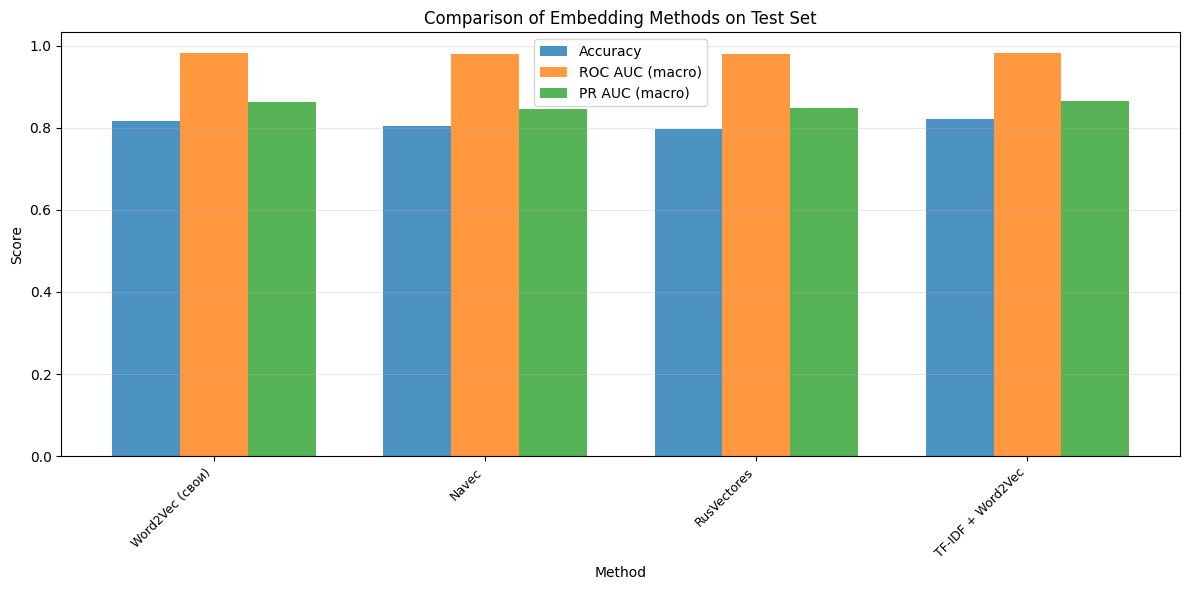

In [28]:
plt.figure(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.25

plt.bar(x - width, results_df['Accuracy'], width, label='Accuracy', alpha=0.8)
plt.bar(x, results_df['ROC AUC'], width, label='ROC AUC (macro)', alpha=0.8)
plt.bar(x + width, results_df['PR AUC'], width, label='PR AUC (macro)', alpha=0.8)

plt.xlabel('Method')
plt.ylabel('Score')
plt.title('Comparison of Embedding Methods on Test Set')
plt.xticks(x, results_df['Method'], rotation=45, ha='right', fontsize=9)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Classification Report для лучшей модели

In [29]:
unique_labels = np.unique(y_test)
classes_actual = [classes[i] for i in unique_labels]
print(classification_report(y_test, test_pred_tfidf, labels=unique_labels, target_names=classes_actual))

                   precision    recall  f1-score   support

   69-я параллель       0.80      0.33      0.47        36
      Бывший СССР       0.83      0.79      0.81       286
              Дом       0.89      0.72      0.80       141
         Из жизни       0.81      0.86      0.83       268
   Интернет и СМИ       0.73      0.74      0.73       295
         Культура       0.88      0.85      0.87       252
              Мир       0.80      0.89      0.84       548
  Наука и техника       0.87      0.85      0.86       266
      Путешествия       0.86      0.60      0.70       121
           Россия       0.73      0.76      0.75       580
Силовые структуры       0.79      0.76      0.77       230
            Спорт       0.96      0.96      0.96       425
         Ценности       0.92      0.85      0.88       150
        Экономика       0.80      0.86      0.83       401

         accuracy                           0.82      3999
        macro avg       0.83      0.77      0.79      

ROC Curve - Macro Average

In [30]:
from sklearn.metrics import roc_curve, precision_recall_curve

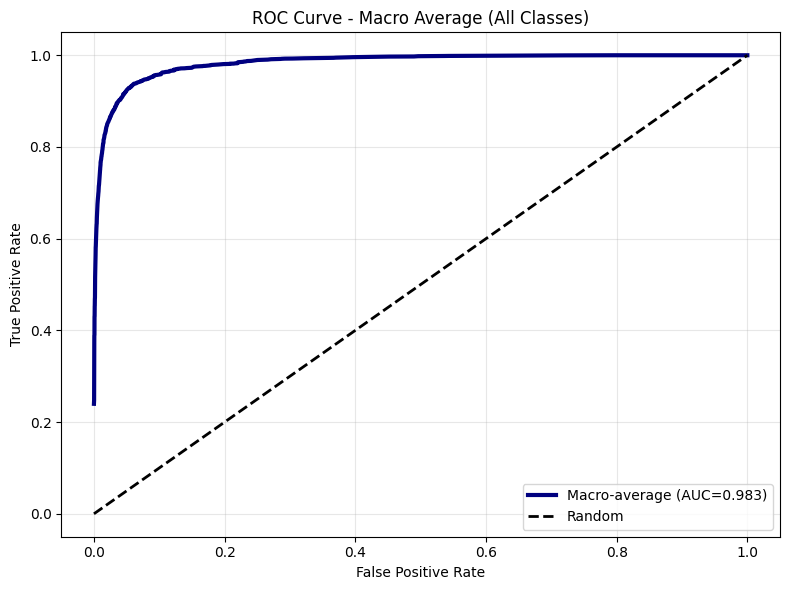

In [31]:
y_test_bin = label_binarize(y_test, classes=unique_labels)
n_classes = len(unique_labels)

fpr = dict()
tpr = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], test_proba_tfidf[:, i])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes

from sklearn.metrics import auc
plt.figure(figsize=(8, 6))
plt.plot(all_fpr, mean_tpr, color='navy', linewidth=3,
         label=f'Macro-average (AUC={auc(all_fpr, mean_tpr):.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Macro Average (All Classes)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ROC-AUC используется как основная метрика, потому что в задаче есть несколько классов и они распределены неравномерно. Accuracy показывает только долю правильных ответов и может быть завышена за счет частых тем, например «Россия» или «Мир». ROC-AUC macro оценивает, насколько хорошо модель ранжирует объекты по вероятностям для каждого класса, а затем усредняет результат по классам(макроусреднение). Поэтому эта метрика лучше отражает качество модели не только на популярных, но и на менее частых темах.

Precision-Recall Curve - Macro Average

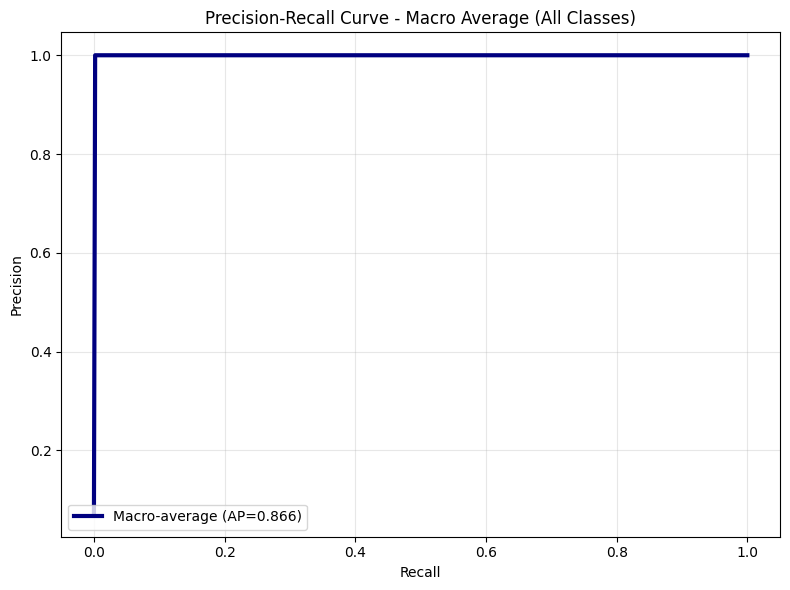

In [32]:
precision = dict()
recall = dict()
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], test_proba_tfidf[:, i])

all_recall = np.unique(np.concatenate([recall[i] for i in range(n_classes)]))
mean_precision = np.zeros_like(all_recall)
for i in range(n_classes):
    mean_precision += np.interp(all_recall, recall[i], precision[i])
mean_precision /= n_classes

plt.figure(figsize=(8, 6))
plt.plot(all_recall, mean_precision, color='navy', linewidth=3,
         label=f'Macro-average (AP={average_precision_score(y_test_bin, test_proba_tfidf, average="macro"):.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Macro Average (All Classes)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Примеры ошибок модели

In [33]:
df_test = pd.DataFrame({
    'text': X_test,
    'true': y_test,
    'pred': test_pred_tfidf
})

class_mapper = {i: classes[i] for i in range(len(classes))}
df_test['true_name'] = df_test['true'].map(class_mapper)
df_test['pred_name'] = df_test['pred'].map(class_mapper)

errors = df_test[df_test['true'] != df_test['pred']].sample(10)
print("\nПримеры ошибок модели:")
print(errors[['true_name', 'pred_name']].to_string())


Примеры ошибок модели:
               true_name          pred_name
4766      69-я параллель             Россия
18110             Россия  Силовые структуры
19391             Россия                Дом
2823              Россия        Бывший СССР
16880                Мир     Интернет и СМИ
9433               Спорт     Интернет и СМИ
10032             Россия                Мир
2719                 Мир        Бывший СССР
16747  Силовые структуры             Россия
9166         Путешествия           Из жизни
